In [2]:
from google.colab import files
uploaded = files.upload()

Saving base_pedidos.csv to base_pedidos.csv


#Tratamento da Base de Pedidos

In [3]:
# ============================================
# 1. LEITURA DA BASE DE PEDIDOS
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('base_pedidos.csv', sep=';')

# visualizar tamanho da base, primeiras linhas e tipos de dados
print('Shape original:', df.shape)
display(df.head())
print(df.dtypes)


Shape original: (86708, 7)


,orderid,status,value,cli_document,tipo_cliente,data,data_tratada
0,PED_26F005E0,invoiced,"330,2",CLI_D7A504B8,ANTIGO,31/12/2024,31/12/2024
1,PED_1B660A44,canceled,"330,2",CLI_D7A504B8,ANTIGO,31/12/2024,31/12/2024
2,PED_E6FF3A25,invoiced,"193,81",CLI_70F444F3,ANTIGO,31/12/2024,31/12/2024
3,PED_BBA24339,invoiced,"239,84",CLI_B3CEDCE0,ANTIGO,31/12/2024,31/12/2024
4,PED_62F86C58,invoiced,"351,04",CLI_968226AE,NOVO,31/12/2024,31/12/2024


orderid         object
status          object
value           object
cli_document    object
tipo_cliente    object
data            object
data_tratada    object
dtype: object


In [4]:
# ============================================
# 2. LIMPEZA DOS NOMES DAS COLUNAS
# ============================================

# cópia de segurança
df_raw = df.copy()

# corrigir nomes das colunas
df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

print('Colunas:')
print(df.columns.tolist())

# remover linhas totalmente vazias
df = df.dropna(how='all').copy()

print('Shape após remover linhas totalmente vazias:', df.shape)

Colunas:
['orderid', 'status', 'value', 'cli_document', 'tipo_cliente', 'data', 'data_tratada']
Shape após remover linhas totalmente vazias: (86708, 7)


In [5]:
# ============================================
# 3. LIMPEZA DE COLUNAS DE TEXTO
# ============================================

# remover espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

# remover espaços extras nas colunas de texto
colunas_texto = ['orderid', 'status', 'cli_document', 'tipo_cliente', 'data', 'data_tratada']

for col in colunas_texto:
    df[col] = df[col].astype(str).str.strip()

# padronizar status e tipo_cliente
df['status'] = df['status'].astype(str).str.strip().str.title()
df['tipo_cliente'] = df['tipo_cliente'].astype(str).str.strip().str.title()

display(df.head())

,orderid,status,value,cli_document,tipo_cliente,data,data_tratada
0,PED_26F005E0,Invoiced,"330,2",CLI_D7A504B8,Antigo,31/12/2024,31/12/2024
1,PED_1B660A44,Canceled,"330,2",CLI_D7A504B8,Antigo,31/12/2024,31/12/2024
2,PED_E6FF3A25,Invoiced,"193,81",CLI_70F444F3,Antigo,31/12/2024,31/12/2024
3,PED_BBA24339,Invoiced,"239,84",CLI_B3CEDCE0,Antigo,31/12/2024,31/12/2024
4,PED_62F86C58,Invoiced,"351,04",CLI_968226AE,Novo,31/12/2024,31/12/2024


In [6]:
df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

print('\nColunas após limpeza estrutural do nome:')
print(df.columns.tolist())


Colunas após limpeza estrutural do nome:
['orderid', 'status', 'value', 'cli_document', 'tipo_cliente', 'data', 'data_tratada']


In [7]:
# ============================================
# 4. CONVERSÃO DO VALUE PARA FLOAT
# ============================================

# value está como string com vírgula decimal
# exemplo: 330,20

df['value'] = (
    df['value']
    .astype(str)
    .str.replace('.', '', regex=False)   # caso exista separador de milhar
    .str.replace(',', '.', regex=False)  # troca vírgula decimal por ponto
)

# converter para número
df['value'] = pd.to_numeric(df['value'], errors='coerce')

print(df['value'].dtype)
print("\nNulos em value após conversão:", df['value'].isnull().sum())

display(df[['value']].head())

float64

Nulos em value após conversão: 0


,value
0,330.20
1,330.20
2,193.81
3,239.84
4,351.04


In [8]:
# ============================================
# 5. CONVERSÃO DAS DATAS
# ============================================

# converter para datetime
df['data_tratada'] = pd.to_datetime(df['data_tratada'], format='%d/%m/%Y', errors='coerce')


print("Nulos em data_tratada:", df['data_tratada'].isnull().sum())

display(df.head())

Nulos em data_tratada: 0


,orderid,status,value,cli_document,tipo_cliente,data,data_tratada
0,PED_26F005E0,Invoiced,330.20,CLI_D7A504B8,Antigo,31/12/2024,2024-12-31
1,PED_1B660A44,Canceled,330.20,CLI_D7A504B8,Antigo,31/12/2024,2024-12-31
2,PED_E6FF3A25,Invoiced,193.81,CLI_70F444F3,Antigo,31/12/2024,2024-12-31
3,PED_BBA24339,Invoiced,239.84,CLI_B3CEDCE0,Antigo,31/12/2024,2024-12-31
4,PED_62F86C58,Invoiced,351.04,CLI_968226AE,Novo,31/12/2024,2024-12-31


In [9]:
# ============================================
# 6. ANÁLISE DOS STATUS
# ============================================

# verificar tipos de status
print("Status únicos:")
print(df['status'].value_counts(dropna=False))

print("\nTipo de cliente:")
print(df['tipo_cliente'].value_counts(dropna=False))

Status únicos:
status
Invoiced                  67543
Canceled                  18683
Ready-For-Handling          378
Payment-Approved            102
Request-Cancel                1
Cancellation-Requested        1
Name: count, dtype: int64

Tipo de cliente:
tipo_cliente
Antigo    50003
Novo      36705
Name: count, dtype: int64


In [10]:
# ============================================
# 7. FEATURE ENGINEERING DE TEMPO
# ============================================

# flag de pedido faturado
df['pedido_faturado'] = np.where(df['status'] == 'Invoiced', 1, 0)

# flag de cancelado
df['pedido_cancelado'] = np.where(df['status'] == 'Canceled', 1, 0)

display(df.head())

,orderid,status,value,cli_document,tipo_cliente,data,data_tratada,pedido_faturado,pedido_cancelado
0,PED_26F005E0,Invoiced,330.20,CLI_D7A504B8,Antigo,31/12/2024,2024-12-31,1,0
1,PED_1B660A44,Canceled,330.20,CLI_D7A504B8,Antigo,31/12/2024,2024-12-31,0,1
2,PED_E6FF3A25,Invoiced,193.81,CLI_70F444F3,Antigo,31/12/2024,2024-12-31,1,0
3,PED_BBA24339,Invoiced,239.84,CLI_B3CEDCE0,Antigo,31/12/2024,2024-12-31,1,0
4,PED_62F86C58,Invoiced,351.04,CLI_968226AE,Novo,31/12/2024,2024-12-31,1,0


In [11]:
# Conferir se há pedidos duplicados
print("Order IDs duplicados:", df['orderid'].duplicated().sum())
print("Clientes únicos:", df['cli_document'].nunique())

Order IDs duplicados: 0
Clientes únicos: 52247


In [12]:
# ============================================
# 8. FILTRAR APENAS PEDIDOS FATURADOS
# ============================================

# pedidos cancelados não representam compra
# df_cancelados = df.copy()
# df = df[df['status'] == 'Invoiced'].copy()

# print("Shape após manter apenas Invoiced:", df.shape)
# print("\nStatus restantes:")
# print(df['status'].value_counts())
# display(df.head())

In [13]:
# ============================================
# 9. ORDENAR PEDIDOS
# ============================================

# ordenar por cliente e data
df = df.sort_values(['cli_document', 'data_tratada'])

print("Dados ordenados por cliente e data")
display(df[['cli_document', 'orderid', 'data_tratada']].head(10))

Dados ordenados por cliente e data


,cli_document,orderid,data_tratada
6270,CLI_000059B4,PED_F41193D8,2024-11-28
62393,CLI_00020501,PED_BFE831E4,2023-11-23
55732,CLI_00020501,PED_EBD441A7,2024-01-05
54686,CLI_00020501,PED_D4DFF5AF,2024-01-15
31781,CLI_0002817B,PED_3B0C64A6,2024-07-08
31784,CLI_0002817B,PED_BC815093,2024-07-08
31786,CLI_0002817B,PED_C7416AED,2024-07-08
66267,CLI_0005815F,PED_586C7DBA,2023-11-07
68473,CLI_00058283,PED_39444FA8,2023-10-26
41595,CLI_0006252F,PED_BFF31BCE,2024-04-24


In [14]:
# ============================================
# 10. NUMERO DA COMPRA DO CLIENTE
# ============================================


# numerar compras apenas para pedidos faturados
df['numero_compra_cliente'] = (
    df[df['pedido_faturado'] == 1]
    .groupby('cli_document')
    .cumcount() + 1
)


print("Distribuição do número de compras:")
print(df['numero_compra_cliente'].value_counts().head())

display(
    df[
        [
            'cli_document',
            'orderid',
            'status',
            'numero_compra_cliente',
            'data_tratada'
        ]
    ].head(10)
)
# 1.0 - primeira compra, 2.0 - segunda compra, etc

Distribuição do número de compras:
numero_compra_cliente
1.0    47133
2.0    11073
3.0     4292
4.0     2082
5.0     1095
Name: count, dtype: int64


,cli_document,orderid,status,numero_compra_cliente,data_tratada
6270,CLI_000059B4,PED_F41193D8,Invoiced,1.0,2024-11-28
62393,CLI_00020501,PED_BFE831E4,Invoiced,1.0,2023-11-23
55732,CLI_00020501,PED_EBD441A7,Invoiced,2.0,2024-01-05
54686,CLI_00020501,PED_D4DFF5AF,Invoiced,3.0,2024-01-15
31781,CLI_0002817B,PED_3B0C64A6,Canceled,NaN,2024-07-08
31784,CLI_0002817B,PED_BC815093,Canceled,NaN,2024-07-08
31786,CLI_0002817B,PED_C7416AED,Canceled,NaN,2024-07-08
66267,CLI_0005815F,PED_586C7DBA,Invoiced,1.0,2023-11-07
68473,CLI_00058283,PED_39444FA8,Invoiced,1.0,2023-10-26
41595,CLI_0006252F,PED_BFF31BCE,Invoiced,1.0,2024-04-24


In [15]:
# ============================================
# 11. FLAG DE RECOMPRA
# ============================================

# recompra apenas para pedidos faturados
df['recompra'] = np.where(
    (df['pedido_faturado'] == 1) & (df['numero_compra_cliente'] > 1),
    1,
    0
)

print("Distribuição da recompra:")
print(df['recompra'].value_counts())

display(
    df[
        [
            'cli_document',
            'orderid',
            'status',
            'numero_compra_cliente',
            'recompra',
            'data_tratada'
        ]
    ].head(15)
)

Distribuição da recompra:
recompra
0    66298
1    20410
Name: count, dtype: int64


,cli_document,orderid,status,numero_compra_cliente,recompra,data_tratada
6270,CLI_000059B4,PED_F41193D8,Invoiced,1.0,0,2024-11-28
62393,CLI_00020501,PED_BFE831E4,Invoiced,1.0,0,2023-11-23
55732,CLI_00020501,PED_EBD441A7,Invoiced,2.0,1,2024-01-05
54686,CLI_00020501,PED_D4DFF5AF,Invoiced,3.0,1,2024-01-15
31781,CLI_0002817B,PED_3B0C64A6,Canceled,NaN,0,2024-07-08
31784,CLI_0002817B,PED_BC815093,Canceled,NaN,0,2024-07-08
31786,CLI_0002817B,PED_C7416AED,Canceled,NaN,0,2024-07-08
66267,CLI_0005815F,PED_586C7DBA,Invoiced,1.0,0,2023-11-07
68473,CLI_00058283,PED_39444FA8,Invoiced,1.0,0,2023-10-26
41595,CLI_0006252F,PED_BFF31BCE,Invoiced,1.0,0,2024-04-24


In [16]:
# ============================================
# 12. TEMPO ENTRE COMPRAS
# ============================================

# ordenar por cliente e data
df = df.sort_values(['cli_document', 'data_tratada'])

# criar coluna vazia
df['data_compra_anterior'] = pd.NaT

# considerar apenas pedidos faturados
mask = df['pedido_faturado'] == 1

df.loc[mask, 'data_compra_anterior'] = (
    df[mask]
    .groupby('cli_document')['data_tratada']
    .shift(1)
)

# calcular dias entre compras
df['dias_para_recompra'] = (
    df['data_tratada'] - df['data_compra_anterior']
).dt.days


print("Dias para recompra:")
display(
    df[
        [
            'cli_document',
            'orderid',
            'status',
            'data_tratada',
            'data_compra_anterior',
            'dias_para_recompra'
        ]
    ].head(15)
)

print("\nEstatísticas:")
print(df['dias_para_recompra'].describe())

Dias para recompra:


,cli_document,orderid,status,data_tratada,data_compra_anterior,dias_para_recompra
6270,CLI_000059B4,PED_F41193D8,Invoiced,2024-11-28,NaT,NaN
62393,CLI_00020501,PED_BFE831E4,Invoiced,2023-11-23,NaT,NaN
55732,CLI_00020501,PED_EBD441A7,Invoiced,2024-01-05,2023-11-23,43.0
54686,CLI_00020501,PED_D4DFF5AF,Invoiced,2024-01-15,2024-01-05,10.0
31781,CLI_0002817B,PED_3B0C64A6,Canceled,2024-07-08,NaT,NaN
31784,CLI_0002817B,PED_BC815093,Canceled,2024-07-08,NaT,NaN
31786,CLI_0002817B,PED_C7416AED,Canceled,2024-07-08,NaT,NaN
66267,CLI_0005815F,PED_586C7DBA,Invoiced,2023-11-07,NaT,NaN
68473,CLI_00058283,PED_39444FA8,Invoiced,2023-10-26,NaT,NaN
41595,CLI_0006252F,PED_BFF31BCE,Invoiced,2024-04-24,NaT,NaN



Estatísticas:
count    20410.000000
mean       124.992210
std        109.039763
min          0.000000
25%         42.000000
50%         93.000000
75%        177.000000
max        534.000000
Name: dias_para_recompra, dtype: float64


In [17]:
# ============================================
# 13. RECOMPRA VÁLIDA
# ============================================

# remover dias 0
df_recompra = df[df['dias_para_recompra'] > 0]

print("Shape recompra válida:", df_recompra.shape)

print("\nEstatísticas limpas:")
print(df_recompra['dias_para_recompra'].describe())

Shape recompra válida: (19982, 13)

Estatísticas limpas:
count    19982.000000
mean       127.669453
std        108.639456
min          1.000000
25%         46.000000
50%         95.000000
75%        180.000000
max        534.000000
Name: dias_para_recompra, dtype: float64


In [18]:
# ============================================
# 14. TABELA DE CLIENTES
# ============================================

# considerar apenas pedidos faturados
df_faturado = df[df['pedido_faturado'] == 1].copy()

clientes = df_faturado.groupby('cli_document').agg(
    total_pedidos=('orderid', 'count'),
    faturamento_total=('value', 'sum'),
    ticket_medio=('value', 'mean'),
    primeira_compra=('data_tratada', 'min'),
    ultima_compra=('data_tratada', 'max')
).reset_index()

print("Shape tabela clientes:", clientes.shape)
display(clientes.head())

Shape tabela clientes: (47133, 6)


,cli_document,total_pedidos,faturamento_total,ticket_medio,primeira_compra,ultima_compra
0,CLI_000059B4,1,190.42,190.420000,2024-11-28,2024-11-28
1,CLI_00020501,3,440.17,146.723333,2023-11-23,2024-01-15
2,CLI_0005815F,1,69.93,69.930000,2023-11-07,2023-11-07
3,CLI_00058283,1,328.80,328.800000,2023-10-26,2023-10-26
4,CLI_0006252F,1,637.90,637.900000,2024-04-24,2024-04-24


In [19]:
# cliente recorrente
clientes['cliente_recorrente'] = (
    clientes['total_pedidos'] > 1
).astype(int)

print("Clientes recorrentes:")
print(clientes['cliente_recorrente'].value_counts())

display(clientes.head())

Clientes recorrentes:
cliente_recorrente
0    36060
1    11073
Name: count, dtype: int64


,cli_document,total_pedidos,faturamento_total,ticket_medio,primeira_compra,ultima_compra,cliente_recorrente
0,CLI_000059B4,1,190.42,190.420000,2024-11-28,2024-11-28,0
1,CLI_00020501,3,440.17,146.723333,2023-11-23,2024-01-15,1
2,CLI_0005815F,1,69.93,69.930000,2023-11-07,2023-11-07,0
3,CLI_00058283,1,328.80,328.800000,2023-10-26,2023-10-26,0
4,CLI_0006252F,1,637.90,637.900000,2024-04-24,2024-04-24,0


In [20]:
# ============================================
# 15. MÉTRICAS DE RECOMPRA
# ============================================

percentual_recompra = clientes['cliente_recorrente'].mean() * 100

print(f"Percentual de clientes que recompram: {percentual_recompra:.2f}%")

Percentual de clientes que recompram: 23.49%


In [21]:
tempo_medio = df['dias_para_recompra'].mean()
tempo_mediano = df['dias_para_recompra'].median()

print(f"Tempo médio para recompra: {tempo_medio:.2f} dias")
print(f"Tempo mediano para recompra: {tempo_mediano:.2f} dias")

Tempo médio para recompra: 124.99 dias
Tempo mediano para recompra: 93.00 dias


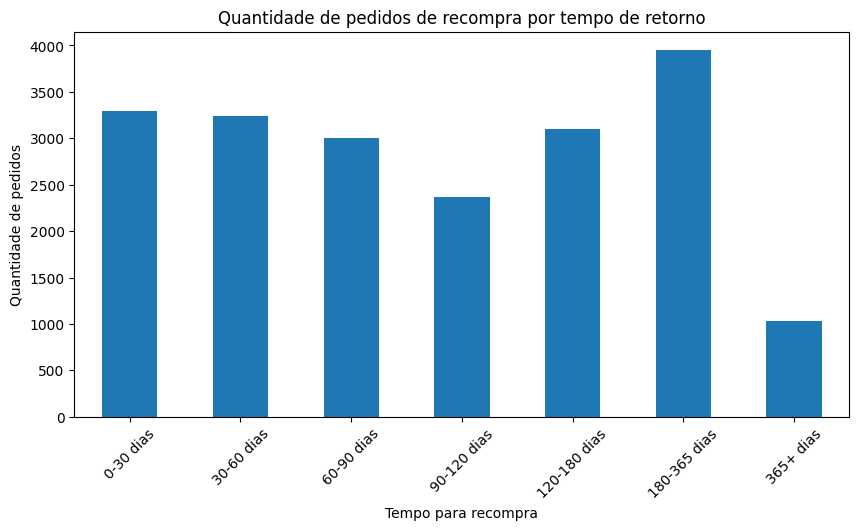

Recompras até 30 dias: 3299
Recompras até 60 dias: 6537
Recompras até 90 dias: 9537
Recompras até 120 dias: 11903
Recompras até 180 dias: 14998
Recompras até 365 dias: 18948


In [22]:
# garantir apenas recompras
recompras = df_recompra[df_recompra['dias_para_recompra'] > 0].copy()

# criar faixas
bins = [0, 30, 60, 90, 120, 180, 365, 1000]
labels = [
    '0-30 dias',
    '30-60 dias',
    '60-90 dias',
    '90-120 dias',
    '120-180 dias',
    '180-365 dias',
    '365+ dias'
]

recompras['faixa_recompra'] = pd.cut(
    recompras['dias_para_recompra'],
    bins=bins,
    labels=labels
)

# contar quantidade
grafico = (
    recompras['faixa_recompra']
    .value_counts()
    .sort_index()
)

# plot
plt.figure(figsize=(10,5))
grafico.plot(kind='bar')

plt.title("Quantidade de pedidos de recompra por tempo de retorno")
plt.xlabel("Tempo para recompra")
plt.ylabel("Quantidade de pedidos")

plt.xticks(rotation=45)

plt.show()

ate_30_qtd = (df_recompra['dias_para_recompra'] <= 30).sum()
ate_60_qtd = (df_recompra['dias_para_recompra'] <= 60).sum()
ate_90_qtd = (df_recompra['dias_para_recompra'] <= 90).sum()
ate_120_qtd = (df_recompra['dias_para_recompra'] <= 120).sum()
ate_180_qtd = (df_recompra['dias_para_recompra'] <= 180).sum()
ate_365_qtd = (df_recompra['dias_para_recompra'] <= 365).sum()

print(f"Recompras até 30 dias: {ate_30_qtd}")
print(f"Recompras até 60 dias: {ate_60_qtd}")
print(f"Recompras até 90 dias: {ate_90_qtd}")
print(f"Recompras até 120 dias: {ate_120_qtd}")
print(f"Recompras até 180 dias: {ate_180_qtd}")
print(f"Recompras até 365 dias: {ate_365_qtd}")

In [23]:
# ============================================
# 16. JANELA DE RECOMPRA
# ============================================

ate_30 = (df_recompra['dias_para_recompra'] <= 30).mean() * 100
ate_60 = (df_recompra['dias_para_recompra'] <= 60).mean() * 100
ate_90 = (df_recompra['dias_para_recompra'] <= 90).mean() * 100

print(f"Recompra até 30 dias: {ate_30:.2f}%")
print(f"Recompra até 60 dias: {ate_60:.2f}%")
print(f"Recompra até 90 dias: {ate_90:.2f}%")

Recompra até 30 dias: 16.51%
Recompra até 60 dias: 32.71%
Recompra até 90 dias: 47.73%


### Insight

A mediana de recompra é de 93 dias, indicando que a maioria dos clientes recompra em até 3 meses.

Isso sugere que campanhas de retenção devem ocorrer entre 30 e 60 dias após a primeira compra.

In [24]:
print("========== RESUMO GERAL ==========\n")

print(f"Clientes únicos: {clientes.shape[0]:,}")
print(f"Pedidos faturados: {df.shape[0]:,}")

print(f"\nPercentual de recompra: {percentual_recompra:.2f}%")
print(f"Tempo médio de recompra: {tempo_medio:.2f} dias")
print(f"Tempo mediano de recompra: {tempo_mediano:.0f} dias")

========== RESUMO GERAL ==========

Clientes únicos: 47,133
Pedidos faturados: 86,708

Percentual de recompra: 23.49%
Tempo médio de recompra: 124.99 dias
Tempo mediano de recompra: 93 dias


In [25]:
df.head()
print(df.columns.tolist())

['orderid', 'status', 'value', 'cli_document', 'tipo_cliente', 'data', 'data_tratada', 'pedido_faturado', 'pedido_cancelado', 'numero_compra_cliente', 'recompra', 'data_compra_anterior', 'dias_para_recompra']


In [26]:
df.to_csv('base_pedidos_tratada.csv', index=False)

In [27]:
from google.colab import files
files.download('base_pedidos_tratada.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>